In [2]:
import time
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import numpy as np
import cv2

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision import transforms
import torchvision.models as models

import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

from tqdm.notebook import tqdm


import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from timm import create_model
from sklearn.metrics import classification_report, confusion_matrix
import random
from PIL import Image
import os


from sklearn.metrics import accuracy_score
import PIL
import matplotlib.pyplot as plt
import seaborn as sns

import time
from collections import OrderedDict

import platform
import psutil

import random
import glob
from tqdm import tqdm

from PIL import Image
from torchvision import transforms
from PIL import ImageOps

from tabulate import tabulate
from torchvision import transforms


In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [3]:
!pip install torch torchvision timm matplotlib scikit-learn seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 80.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 65.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.9 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.

In [4]:
!pip install pydicom

In [5]:
%matplotlib inline


In [6]:
# Install necessary packages
!pip install timm torch torchvision matplotlib scikit-learn seaborn pydicom

In [7]:
import os

# Set the path to your dataset folder
dataset_path = '/kaggle/input/mract1/Paired MRI (T1, T2) and CT Scans Dataset'

# Verify the dataset contents
print(os.listdir(dataset_path))  # This will list all files in the folder


['CT', 'T1-MRI', 'T2-MRI']


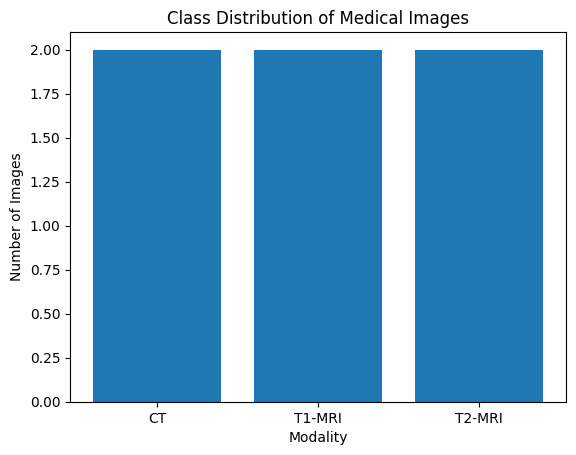

In [8]:
import matplotlib.pyplot as plt
import os

def plot_class_distribution(dataset_path):
    class_counts = {
        "CT": len([f for f in os.listdir(os.path.join(dataset_path, 'CT'))]),
        "T1-MRI": len([f for f in os.listdir(os.path.join(dataset_path, 'T1-MRI'))]),
        "T2-MRI": len([f for f in os.listdir(os.path.join(dataset_path, 'T2-MRI'))])
    }

    plt.bar(class_counts.keys(), class_counts.values())
    plt.xlabel("Modality")
    plt.ylabel("Number of Images")
    plt.title("Class Distribution of Medical Images")
    plt.show()

# Example usage:
dataset_path = "/kaggle/input/mract1/Paired MRI (T1, T2) and CT Scans Dataset"
plot_class_distribution(dataset_path)


In [9]:
import os

# Define the folder paths for each modality
ct_folder = '/kaggle/input/mract1/Paired MRI (T1, T2) and CT Scans Dataset/CT'
t1_mri_folder = '/kaggle/input/mract1/Paired MRI (T1, T2) and CT Scans Dataset/T1-MRI'
t2_mri_folder = '/kaggle/input/mract1/Paired MRI (T1, T2) and CT Scans Dataset/T2-MRI'

# Function to count PNG and DICOM images in a folder
def count_images_in_folder(folder_path):
    print(f"Checking folder: {folder_path}")  # Print the folder path being checked
    png_count = 0
    dicom_count = 0
    for patient_folder in os.listdir(folder_path):
        patient_path = os.path.join(folder_path, patient_folder)
        if os.path.isdir(patient_path):  # Check if it's a folder
            print(f"Found patient folder: {patient_folder}")  # Debugging patient folder
            for subfolder in os.listdir(patient_path):  # Check inside the patient folder
                subfolder_path = os.path.join(patient_path, subfolder)
                if os.path.isdir(subfolder_path):  # Check if subfolder exists (PNG/DICOM)
                    print(f"Found subfolder: {subfolder}")  # Debugging subfolder name
                    for image_name in os.listdir(subfolder_path):  # List files in the subfolder
                        if image_name.endswith('.png'):  # Count PNG files
                            png_count += 1
                        elif image_name.endswith('.dcm'):  # Count DICOM files
                            dicom_count += 1
    return png_count, dicom_count

# Count images in each modality folder
ct_png_count, ct_dicom_count = count_images_in_folder(ct_folder)
t1_mri_png_count, t1_mri_dicom_count = count_images_in_folder(t1_mri_folder)
t2_mri_png_count, t2_mri_dicom_count = count_images_in_folder(t2_mri_folder)

# Display the image counts
print(f"Number of CT PNG images: {ct_png_count}")
print(f"Number of CT DICOM images: {ct_dicom_count}")
print(f"Number of T1-MRI PNG images: {t1_mri_png_count}")
print(f"Number of T1-MRI DICOM images: {t1_mri_dicom_count}")
print(f"Number of T2-MRI PNG images: {t2_mri_png_count}")
print(f"Number of T2-MRI DICOM images: {t2_mri_dicom_count}")


Checking folder: /kaggle/input/mract1/Paired MRI (T1, T2) and CT Scans Dataset/CT
Found patient folder: DICOM
Found subfolder: Patient_09
Found subfolder: Patient_05
Found subfolder: Patient_18
Found subfolder: Patient_03
Found subfolder: Patient_02
Found subfolder: Patient_12
Found subfolder: Patient_15
Found subfolder: Patient_10
Found subfolder: Patient_14
Found subfolder: Patient_04
Found subfolder: Patient_08
Found subfolder: Patient_11
Found subfolder: Patient_17
Found subfolder: Patient_13
Found subfolder: Patient_01
Found subfolder: Patient_07
Found subfolder: Patient_16
Found subfolder: Patient_06
Found patient folder: PNG
Found subfolder: Patient_09
Found subfolder: Patient_05
Found subfolder: Patient_18
Found subfolder: Patient_03
Found subfolder: Patient_02
Found subfolder: Patient_12
Found subfolder: Patient_15
Found subfolder: Patient_10
Found subfolder: Patient_14
Found subfolder: Patient_04
Found subfolder: Patient_08
Found subfolder: Patient_11
Found subfolder: Patient

Displaying CT image:
Patient folders found: ['Patient_09', 'Patient_05', 'Patient_18', 'Patient_03', 'Patient_02', 'Patient_12', 'Patient_15', 'Patient_10', 'Patient_14', 'Patient_04', 'Patient_08', 'Patient_11', 'Patient_17', 'Patient_13', 'Patient_01', 'Patient_07', 'Patient_16', 'Patient_06']
Image files found: ['CT_PNG (2).png', 'CT_PNG (9).png', 'CT_PNG (12).png', 'CT_PNG (6).png', 'CT_PNG (11).png', 'CT_PNG (8).png', 'CT_PNG (3).png', 'CT_PNG (5).png', 'CT_PNG (1).png', 'CT_PNG (4).png', 'CT_PNG (10).png', 'CT_PNG (7).png']


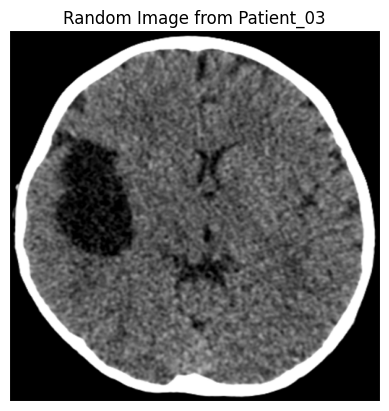

Displaying T1-MRI image:
Patient folders found: ['Patient_09', 'Patient_05', 'Patient_18', 'Patient_03', 'Patient_02', 'Patient_12', 'Patient_15', 'Patient_10', 'Patient_14', 'Patient_04', 'Patient_08', 'Patient_11', 'Patient_17', 'Patient_13', 'Patient_01', 'Patient_07', 'Patient_16', 'Patient_06']
Image files found: ['T1_PNG (7).png', 'T1_PNG (17).png', 'T1_PNG (13).png', 'T1_PNG (20).png', 'T1_PNG (4).png', 'T1_PNG (19).png', 'T1_PNG (8).png', 'T1_PNG (16).png', 'T1_PNG (5).png', 'T1_PNG (6).png', 'T1_PNG (15).png', 'T1_PNG (10).png', 'T1_PNG (11).png', 'T1_PNG (9).png', 'T1_PNG (1).png', 'T1_PNG (12).png', 'T1_PNG (18).png', 'T1_PNG (3).png', 'T1_PNG (14).png', 'T1_PNG (2).png']


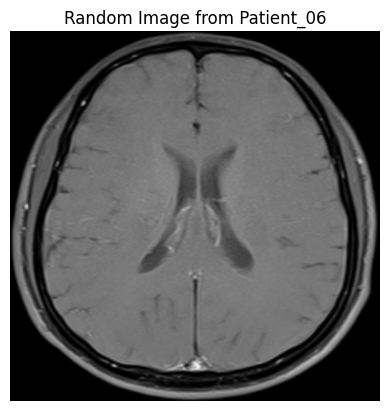

Displaying T2-MRI image:
Patient folders found: ['Patient_09', 'Patient_05', 'Patient_18', 'Patient_03', 'Patient_02', 'Patient_12', 'Patient_15', 'Patient_10', 'Patient_14', 'Patient_04', 'Patient_08', 'Patient_11', 'Patient_17', 'Patient_13', 'Patient_01', 'Patient_07', 'Patient_16', 'Patient_06']
Image files found: ['T2_PNG (12).png', 'T2_PNG (3).png', 'T2_PNG (16).png', 'T2_PNG (4).png', 'T2_PNG (6).png', 'T2_PNG (9).png', 'T2_PNG (11).png', 'T2_PNG (14).png', 'T2_PNG (18).png', 'T2_PNG (5).png', 'T2_PNG (8).png', 'T2_PNG (17).png', 'T2_PNG (1).png', 'T2_PNG (10).png', 'T2_PNG (13).png', 'T2_PNG (2).png', 'T2_PNG (15).png', 'T2_PNG (7).png']


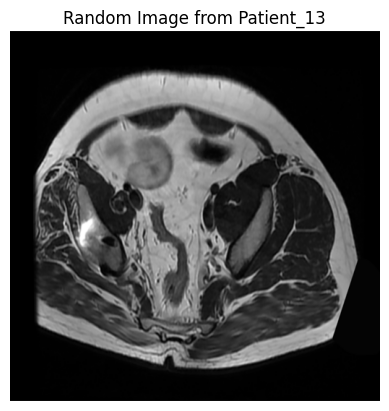

In [11]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Function to display a random image from the PNG folder using matplotlib
def display_random_image(folder_path):
    # We assume the folder directly contains patient folders
    patient_folders = [f for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]

    # Check if there are any patient folders in the directory
    if not patient_folders:
        print(f"No patient folders found in {folder_path}")
        return

    print(f"Patient folders found: {patient_folders}")  # Debugging patient folder names
    patient_folder = random.choice(patient_folders)  # Select a random patient folder

    # Check for image files in the patient folder (checking for PNG, JPG, and JPEG)
    subfolder_path = os.path.join(folder_path, patient_folder)
    image_files = [f for f in os.listdir(subfolder_path) if f.endswith(('.png', '.jpg', '.jpeg')) and not f.startswith('.')]

    # Debugging if no image files are found
    if not image_files:
        print(f"No image files found in {subfolder_path}")
        return

    print(f"Image files found: {image_files}")  # Debugging list of image files
    image_name = random.choice(image_files)  # Pick a random image
    image_path = os.path.join(subfolder_path, image_name)

    # Open the image
    try:
        img = Image.open(image_path)

        # Display the image using matplotlib
        plt.imshow(img)  # Display the image
        plt.axis('off')  # Turn off axis labels
        plt.title(f'Random Image from {patient_folder}')
        plt.show()

    except Exception as e:
        print(f"Error opening image {image_path}: {e}")

# Example usage for each modality
ct_folder = '/kaggle/input/mract1/Paired MRI (T1, T2) and CT Scans Dataset/CT/PNG'  # Path to CT images
t1_mri_folder = '/kaggle/input/mract1/Paired MRI (T1, T2) and CT Scans Dataset/T1-MRI/PNG'  # Path to T1-MRI images
t2_mri_folder = '/kaggle/input/mract1/Paired MRI (T1, T2) and CT Scans Dataset/T2-MRI/PNG'  # Path to T2-MRI images

# Display random images for each modality
print("Displaying CT image:")
display_random_image(ct_folder)  # Display a random CT image

print("Displaying T1-MRI image:")
display_random_image(t1_mri_folder)  # Display a random T1-MRI image

print("Displaying T2-MRI image:")
display_random_image(t2_mri_folder)  # Display a random T2-MRI image


In [13]:
def resize_images_in_folder(folder_path, target_size=(224, 224)):
    resized_images = []
    print(f"Checking folder: {folder_path}")
    for image_name in os.listdir(folder_path):
        if image_name.endswith('.png'):  # Ensure we are working with PNG files
            print(f"Processing {image_name}...")  # Print the file being processed
            image_path = os.path.join(folder_path, image_name)
            img = resize_image(image_path, target_size)
            resized_images.append(img)

    if not resized_images:
        print(f"No images resized in {folder_path}")

    return resized_images


In [14]:
import os
from PIL import Image

# Function to resize images while preserving aspect ratio and padding
def resize_image(image_path, target_size=(224, 224)):
    img = Image.open(image_path)
    img.thumbnail(target_size, Image.Resampling.LANCZOS)  # Resize keeping aspect ratio using LANCZOS resampling
    new_img = Image.new("RGB", target_size, (255, 255, 255))  # Create a blank image with white background
    img_width, img_height = img.size
    new_img.paste(img, ((target_size[0] - img_width) // 2, (target_size[1] - img_height) // 2))  # Padding
    return new_img

# Function to resize images in a folder (for each patient) and save them into respective folders
def resize_and_save_images_in_folder(folder_path, target_size=(224, 224), save_base_folder="resized_images"):
    resized_images = []  # Initialize an empty list to store resized images
    if not os.path.exists(save_base_folder):  # Create the base folder if it does not exist
        os.makedirs(save_base_folder)

    for patient_folder in os.listdir(folder_path):
        patient_path = os.path.join(folder_path, patient_folder)
        if os.path.isdir(patient_path):
            print(f"Processing images for patient: {patient_folder}")
            # Create a subfolder for the patient inside the save folder
            patient_save_folder = os.path.join(save_base_folder, patient_folder)
            if not os.path.exists(patient_save_folder):  # Create subfolder for the patient if it does not exist
                os.makedirs(patient_save_folder)

            for image_name in os.listdir(patient_path):
                if image_name.endswith('.png'):  # Check for PNG files
                    image_path = os.path.join(patient_path, image_name)
                    resized_image = resize_image(image_path, target_size)
                    resized_images.append(resized_image) # Append the resized image to the list

                    # Save the resized image to the patient's subfolder
                    save_path = os.path.join(patient_save_folder, image_name)
                    resized_image.save(save_path)
                    print(f"Processed and saved: {image_name}")

    return resized_images # Return the list of resized images

# Define the paths for each modality folder
ct_folder = '/kaggle/input/mract1/Paired MRI (T1, T2) and CT Scans Dataset/CT/PNG'  # Path to CT images
t1_mri_folder = '/kaggle/input/mract1/Paired MRI (T1, T2) and CT Scans Dataset/T1-MRI/PNG'  # Path to T1-MRI images
t2_mri_folder = '/kaggle/input/mract1/Paired MRI (T1, T2) and CT Scans Dataset/T2-MRI/PNG'   # Path to T2

# Define the directory to save resized images
save_base_folder = '/kaggle/working/ResizedImages'

# Process and save images for each modality and assign to variables
ct_images = resize_and_save_images_in_folder(ct_folder, save_base_folder=os.path.join(save_base_folder, 'CT'))
t1_mri_images = resize_and_save_images_in_folder(t1_mri_folder, save_base_folder=os.path.join(save_base_folder, 'T1-MRI'))
t2_mri_images = resize_and_save_images_in_folder(t2_mri_folder, save_base_folder=os.path.join(save_base_folder, 'T2-MRI'))

# Display a sample resized image for each modality (optional, can be removed later)
#ct_images[0].show()  # Show the first CT image
 #t1_mri_images[0].show()  # Show the first T1-MRI image
 #t2_mri_images[0].show()  # Show the first T2-MRI image

Processing images for patient: Patient_09
Processed and saved: CT_PNG (2).png
Processed and saved: CT_PNG (9).png
Processed and saved: CT_PNG (12).png
Processed and saved: CT_PNG (6).png
Processed and saved: CT_PNG (11).png
Processed and saved: CT_PNG (8).png
Processed and saved: CT_PNG (16).png
Processed and saved: CT_PNG (13).png
Processed and saved: CT_PNG (3).png
Processed and saved: CT_PNG (5).png
Processed and saved: CT_PNG (20).png
Processed and saved: CT_PNG (1).png
Processed and saved: CT_PNG (4).png
Processed and saved: CT_PNG (17).png
Processed and saved: CT_PNG (19).png
Processed and saved: CT_PNG (14).png
Processed and saved: CT_PNG (10).png
Processed and saved: CT_PNG (7).png
Processed and saved: CT_PNG (15).png
Processed and saved: CT_PNG (18).png
Processing images for patient: Patient_05
Processed and saved: CT_PNG (2).png
Processed and saved: CT_PNG (9).png
Processed and saved: CT_PNG (12).png
Processed and saved: CT_PNG (6).png
Processed and saved: CT_PNG (11).png
Pro

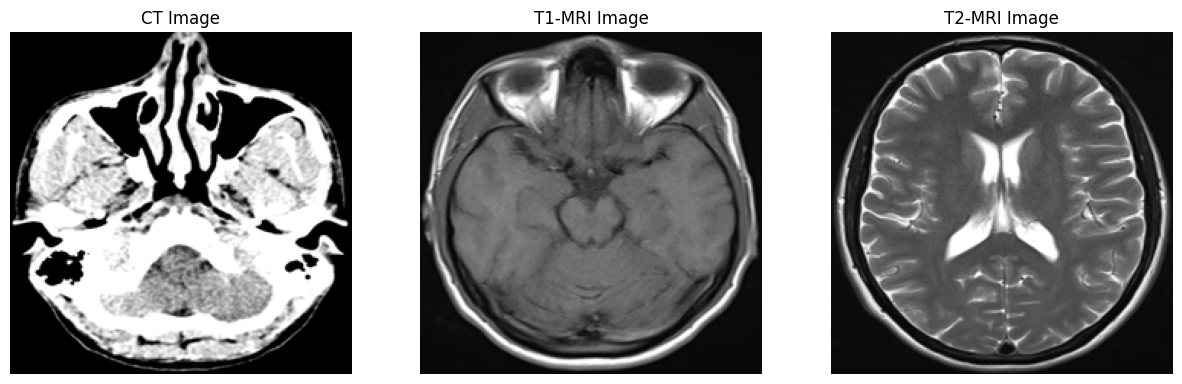

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Function to display images horizontally using matplotlib
def display_images_horizontally(images, titles=None):
    # Set up the figure and axes for horizontal display
    fig, axes = plt.subplots(1, len(images), figsize=(15, 5))

    if titles is None:
        titles = ['Image'] * len(images)  # Default titles

    for i, (img, ax) in enumerate(zip(images, axes)):
        # Convert PIL image to NumPy array for displaying
        ax.imshow(np.array(img), cmap='gray')  # Use 'gray' for grayscale images
        ax.set_title(titles[i])
        ax.axis('off')  # Hide axes

    plt.show()  # Display the images

# Display resized images horizontally (CT, T1-MRI, T2-MRI)
display_images_horizontally([ct_images[0], t1_mri_images[0], t2_mri_images[0]],
                            titles=["CT Image", "T1-MRI Image", "T2-MRI Image"])

In [16]:
import os

# Check if the directories and image files exist
resized_images_path = '/kaggle/working/ResizedImages'


# List the files in each directory
print(f"Files in {resized_images_path}: {os.listdir(resized_images_path)}")



Files in /kaggle/working/ResizedImages: ['T1-MRI', 'CT', 'T2-MRI']


Processing modality folder: T1-MRI
Processing patient folder: Patient_10
Processing T1_PNG (5).png...
Processed and saved: T1_PNG (5).png
Processing T1_PNG (13).png...
Processed and saved: T1_PNG (13).png
Processing T1_PNG (4).png...
Processed and saved: T1_PNG (4).png
Processing T1_PNG (2).png...
Processed and saved: T1_PNG (2).png
Processing T1_PNG (15).png...
Processed and saved: T1_PNG (15).png
Processing T1_PNG (6).png...
Processed and saved: T1_PNG (6).png
Processing T1_PNG (7).png...
Processed and saved: T1_PNG (7).png
Processing T1_PNG (19).png...
Processed and saved: T1_PNG (19).png
Processing T1_PNG (1).png...
Processed and saved: T1_PNG (1).png
Processing T1_PNG (10).png...
Processed and saved: T1_PNG (10).png
Processing T1_PNG (11).png...
Processed and saved: T1_PNG (11).png
Processing T1_PNG (12).png...
Processed and saved: T1_PNG (12).png
Processing T1_PNG (18).png...
Processed and saved: T1_PNG (18).png
Processing T1_PNG (17).png...
Processed and saved: T1_PNG (17).png
P

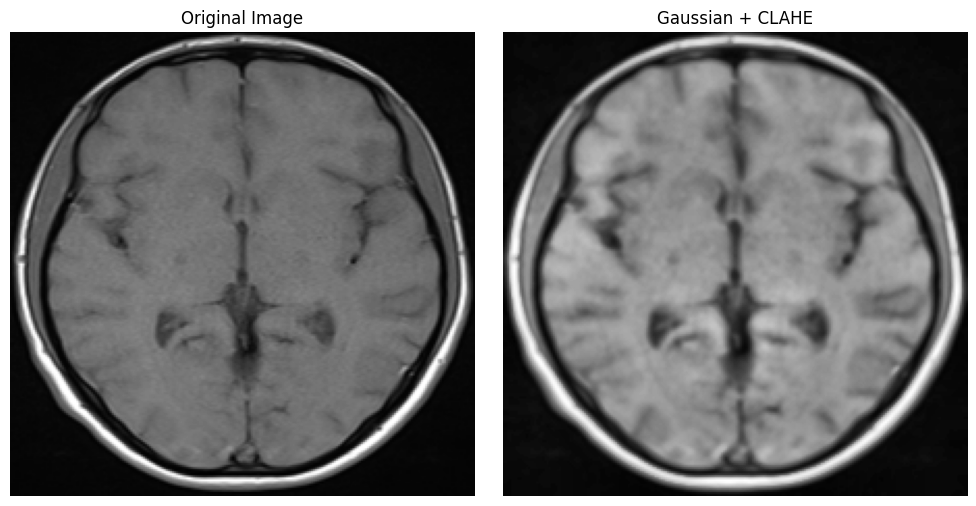

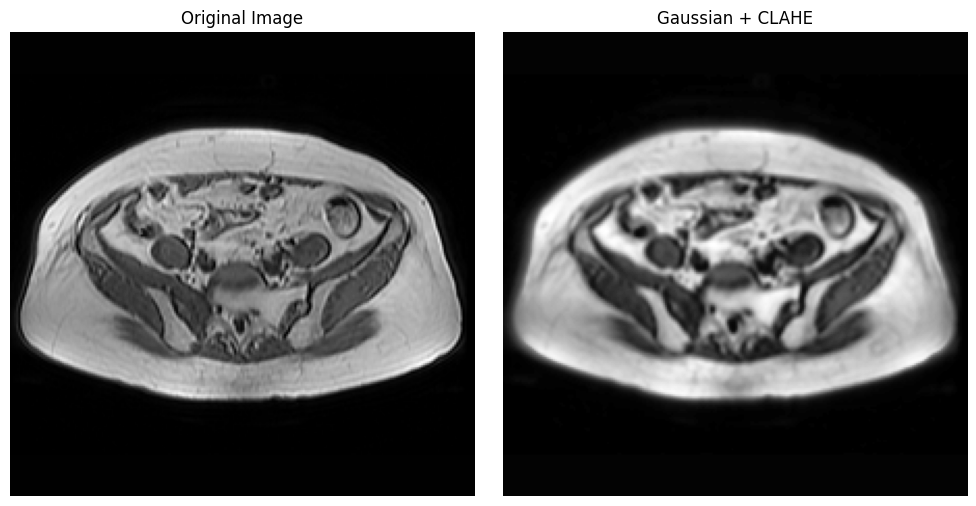

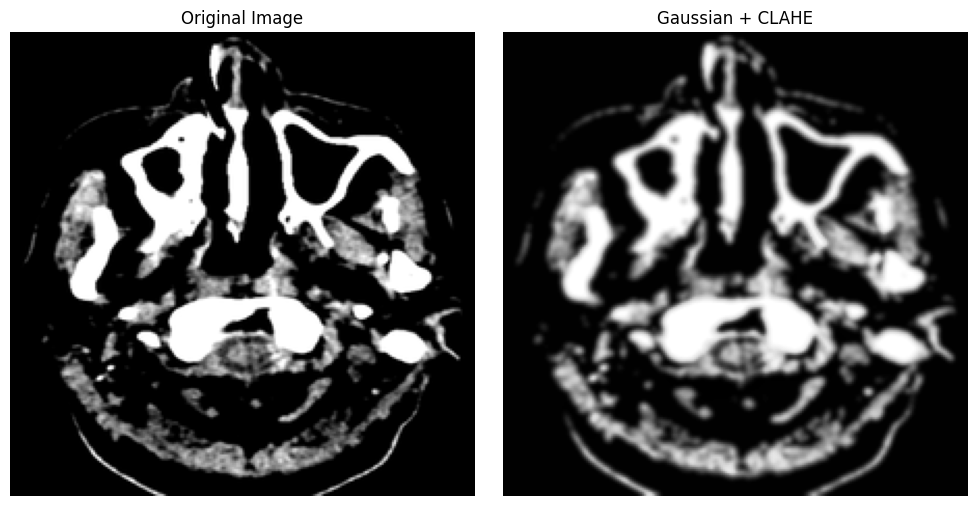

In [17]:
import os
import cv2
import matplotlib.pyplot as plt


# Gaussian filter
def apply_gaussian_filter(image):
    return cv2.GaussianBlur(image, (5, 5), 0)

# Function to apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
def apply_clahe(image):  # Fixed indentation
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(image)

# Function to display original and CLAHE-processed image
def display_processed_images(original, clahe, title_prefix=""):
    plt.figure(figsize=(10, 5))

    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title(f'{title_prefix}Original Image')
    plt.axis('off')

    # CLAHE image
    plt.subplot(1, 2, 2)
    plt.imshow(clahe, cmap='gray')
    plt.title(f'{title_prefix}Gaussian + CLAHE')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Function to process images from a given folder path
def process_images(base_folder, save_base_folder):
    if not os.path.exists(base_folder):
        print(f"Error: The folder {base_folder} does not exist!")
        return

    for modality_folder in os.listdir(base_folder):
        modality_path = os.path.join(base_folder, modality_folder)

        if os.path.isdir(modality_path):
            print(f"Processing modality folder: {modality_folder}")
            save_modality_folder = os.path.join(save_base_folder, modality_folder)
            os.makedirs(save_modality_folder, exist_ok=True)

            for patient_folder in os.listdir(modality_path):
                patient_path = os.path.join(modality_path, patient_folder)

                if os.path.isdir(patient_path):
                    print(f"Processing patient folder: {patient_folder}")
                    save_patient_folder = os.path.join(save_modality_folder, patient_folder)
                    os.makedirs(save_patient_folder, exist_ok=True)

                    for image_name in os.listdir(patient_path):
                        if image_name.endswith('.png'):  # Process only PNG images
                            image_path = os.path.join(patient_path, image_name)

                            # Debugging: Check if image exists before processing
                            if not os.path.isfile(image_path):
                                print(f"Image not found: {image_path}")
                                continue

                            print(f"Processing {image_name}...")  # Debugging

                            # Read the grayscale image
                            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

                            # Check if image was loaded correctly
                            if image is None:
                                print(f"Failed to load image {image_name}")
                                continue  # Skip this image

                            # Apply contrast enhancement techniques
                            gaussian_image = apply_gaussian_filter(image)
                            clahe_image = apply_clahe(gaussian_image) 

                            # Display the results (optional, can be removed later)
                            #display_processed_images(image, clahe_image)

                            # Save processed images into the respective patient folder
                            save_path_clahe = os.path.join(save_patient_folder, f"clahe_{image_name}")
                            success_clahe = cv2.imwrite(save_path_clahe, clahe_image)

                            if not success_clahe:
                                print(f"Error saving image {image_name}")
                            else:
                                print(f"Processed and saved: {image_name}")
def display_random_processed_images(original_base_path, processed_base_path, num_samples=3):
    image_pairs = []

    for modality_folder in os.listdir(processed_base_path):
        modality_path = os.path.join(processed_base_path, modality_folder)
        for patient_folder in os.listdir(modality_path):
            patient_path = os.path.join(modality_path, patient_folder)
            for image_file in os.listdir(patient_path):
                if image_file.startswith("clahe_") and image_file.endswith(".png"):
                    processed_path = os.path.join(patient_path, image_file)
                    original_path = processed_path.replace(processed_base_path, original_base_path).replace("clahe_", "")
                    if os.path.isfile(processed_path) and os.path.isfile(original_path):
                        image_pairs.append((original_path, processed_path))

    if not image_pairs:
        print("No processed images found for display.")
        return

    samples = random.sample(image_pairs, min(num_samples, len(image_pairs)))
    for original_path, processed_path in samples:
        original = cv2.imread(original_path, cv2.IMREAD_GRAYSCALE)
        processed = cv2.imread(processed_path, cv2.IMREAD_GRAYSCALE)
        if original is not None and processed is not None:
            display_processed_images(original, processed)
# Main function to process images from both directories
def process_and_save_images():
    # Define the base folder to save processed images
    save_base_folder = '/kaggle/working/Processed_Images'
    os.makedirs(save_base_folder, exist_ok=True)

    # Define paths to the directories containing the images
    resized_images_path = '/kaggle/working/ResizedImages'
    

    # Process and save resized images and DICOM images into the respective folders
    process_images(resized_images_path, save_base_folder)
    display_random_processed_images(resized_images_path, save_base_folder)

# Call the main function to process and save images
process_and_save_images()


Processing modality folder: T1-MRI
Processing patient folder: Patient_10
Processing clahe_T1_PNG (5).png...
Processed and saved: clahe_T1_PNG (5).png
Processing clahe_T1_PNG (10).png...
Processed and saved: clahe_T1_PNG (10).png
Processing clahe_T1_PNG (16).png...
Processed and saved: clahe_T1_PNG (16).png
Processing clahe_T1_PNG (2).png...
Processed and saved: clahe_T1_PNG (2).png
Processing clahe_T1_PNG (18).png...
Processed and saved: clahe_T1_PNG (18).png
Processing clahe_T1_PNG (9).png...
Processed and saved: clahe_T1_PNG (9).png
Processing clahe_T1_PNG (4).png...
Processed and saved: clahe_T1_PNG (4).png
Processing clahe_T1_PNG (19).png...
Processed and saved: clahe_T1_PNG (19).png
Processing clahe_T1_PNG (13).png...
Processed and saved: clahe_T1_PNG (13).png
Processing clahe_T1_PNG (8).png...
Processed and saved: clahe_T1_PNG (8).png
Processing clahe_T1_PNG (11).png...
Processed and saved: clahe_T1_PNG (11).png
Processing clahe_T1_PNG (14).png...
Processed and saved: clahe_T1_PN

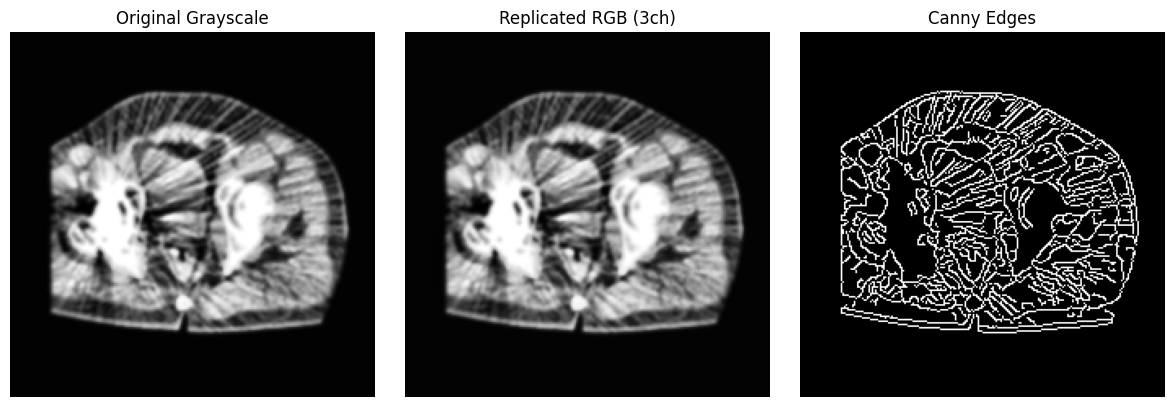

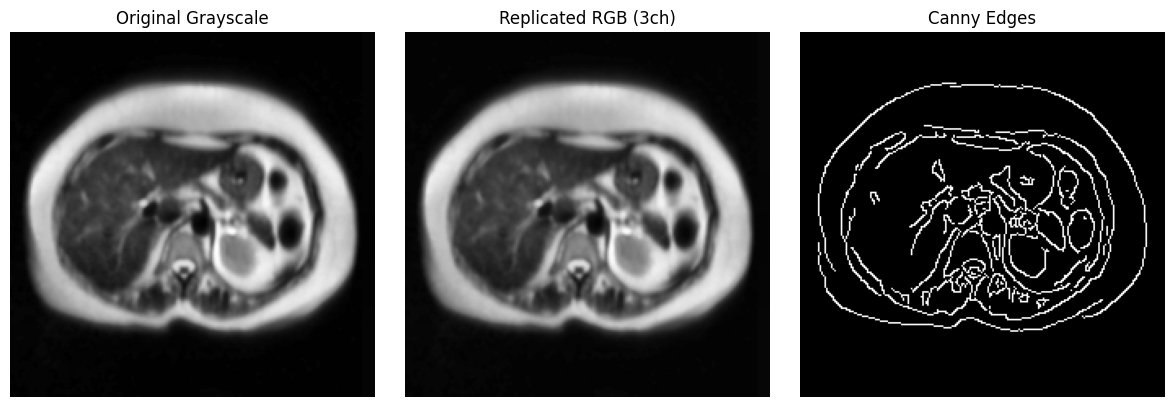

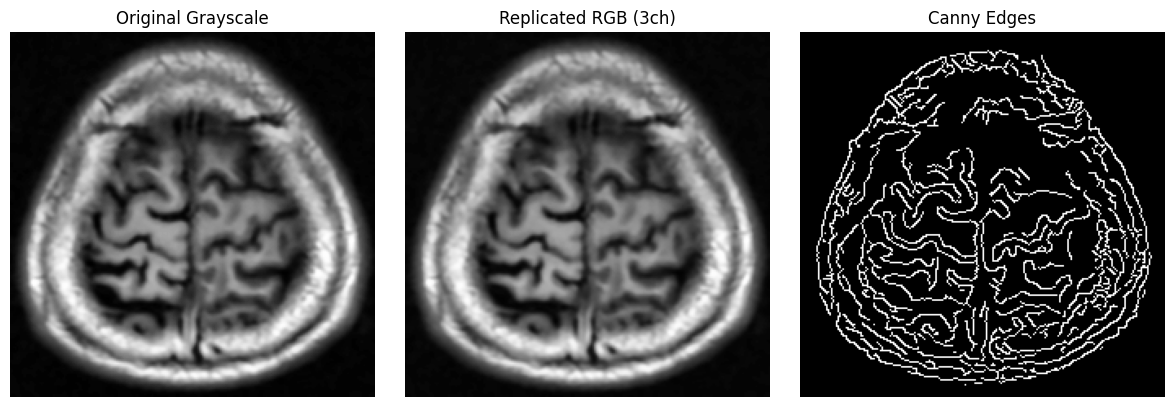

In [18]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# Convert grayscale to RGB (OpenCV method)
def convert_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

# Convert grayscale to 3-channel by replicating the grayscale values
def convert_to_rgb3ch(image):
    return np.stack([image] * 3, axis=-1)

# Apply Canny edge detection
def apply_canny(image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Canny(gray_image, 100, 200)

# Function to display 3 random processed image results
def display_random_processed_images(image_paths):
    print("\nDisplaying 3 randomly selected processed image results...")
    sample_paths = random.sample(image_paths, min(3, len(image_paths)))
    for path_info in sample_paths:
        gray = cv2.imread(path_info['gray'], cv2.IMREAD_GRAYSCALE)
        rgb3ch = cv2.imread(path_info['rgb3ch'])
        canny = cv2.imread(path_info['canny'], cv2.IMREAD_GRAYSCALE)

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(gray, cmap='gray')
        plt.title("Original Grayscale")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(rgb3ch)
        plt.title("Replicated RGB (3ch)")
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(canny, cmap='gray')
        plt.title("Canny Edges")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

# Process images in folder
def process_images(base_folder, save_base_folder):
    if not os.path.exists(base_folder):
        print(f"Error: The folder {base_folder} does not exist!")
        return

    saved_paths = []  # Collect processed paths for random display

    for modality_folder in os.listdir(base_folder):
        modality_path = os.path.join(base_folder, modality_folder)
        if not os.path.isdir(modality_path):
            continue

        print(f"Processing modality folder: {modality_folder}")
        save_modality_folder = os.path.join(save_base_folder, modality_folder)
        os.makedirs(save_modality_folder, exist_ok=True)

        for patient_folder in os.listdir(modality_path):
            patient_path = os.path.join(modality_path, patient_folder)
            if not os.path.isdir(patient_path):
                continue

            print(f"Processing patient folder: {patient_folder}")
            save_patient_folder = os.path.join(save_modality_folder, patient_folder)
            os.makedirs(save_patient_folder, exist_ok=True)

            for image_name in os.listdir(patient_path):
                if not image_name.endswith('.png'):
                    continue

                image_path = os.path.join(patient_path, image_name)
                if not os.path.isfile(image_path):
                    print(f"Image not found: {image_path}")
                    continue

                print(f"Processing {image_name}...")
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                if image is None:
                    print(f"Failed to load image {image_name}")
                    continue

                # Convert and apply filters
                rgb_image = convert_to_rgb(image)
                replicated_image = convert_to_rgb3ch(image)
                canny_image = apply_canny(rgb_image)

                # Save paths
                save_path_rgb3ch = os.path.join(save_patient_folder, f"rgb3ch_{image_name}")
                save_path_canny = os.path.join(save_patient_folder, f"canny_{image_name}")
                success_rgb3ch = cv2.imwrite(save_path_rgb3ch, replicated_image)
                success_canny = cv2.imwrite(save_path_canny, canny_image)

                if success_rgb3ch and success_canny:
                    saved_paths.append({
                        'gray': image_path,
                        'rgb3ch': save_path_rgb3ch,
                        'canny': save_path_canny
                    })
                    print(f"Processed and saved: {image_name}")
                else:
                    print(f"Error saving image {image_name}")

    # Display 3 random results
    if saved_paths:
        display_random_processed_images(saved_paths)

# Wrapper function
def process_and_save_extra_images():
    save_base_folder = '/kaggle/working/Processed_Images_Extra'
    os.makedirs(save_base_folder, exist_ok=True)

    processed_images_path = '/kaggle/working/Processed_Images'
    process_images(processed_images_path, save_base_folder)

# Run
process_and_save_extra_images()


In [17]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Define the transformation pipeline for the training dataset (with augmentation)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),  # Convert the image to tensor
    transforms.Normalize([0.5]*3, [0.5]*3),
    torchvision.transforms.RandomResizedCrop(224),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1)),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.1))
])

# Define the transformation pipeline for the validation and test datasets (no augmentation)
val_test_transform = transforms.Compose([
   
    transforms.ToTensor(),  # Convert the image to tensor
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset_path = '/kaggle/working/Processed_Images_Extra'

# Load the dataset with different transforms for train, validation, and test
dataset = datasets.ImageFolder(root=dataset_path, transform=train_transform)

# Split the dataset into train, validation, and test sets
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Apply the validation/test transform to the val and test datasets
val_dataset.dataset.transform = val_test_transform
test_dataset.dataset.transform = val_test_transform


# Create DataLoader for training, validation, and test datasets
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Fetch a batch of images to check
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)


torch.Size([16, 3, 224, 224]) torch.Size([16])


**Vit base 16**

In [10]:
import timm
import torch.nn as nn
from torchvision import models
import torch.optim as optim
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.models import MobileNet_V3_Large_Weights
from torchvision.models import DenseNet121_Weights
# Define model selection with Dropout before final layer
def get_model(model_name):
    if model_name == "ConvNeXt-Tiny":
        model = timm.create_model("convnext_tiny.fb_in22k", pretrained=True)
        model.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(model.num_features * 7 * 7, 3)
        )
    elif model_name == "DenseNet-121":
        weights = DenseNet121_Weights.DEFAULT
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.classifier.in_features, 3)
        )
    elif model_name == "EfficientNet-V2-Small":
        model = timm.create_model("efficientnet_v2_s", pretrained=True)
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.classifier.in_features, 3)
        )
    elif model_name == "MobileNet-V3-Large":
        weights = MobileNet_V3_Large_Weights.DEFAULT 
        model = models.mobilenet_v3_large(weights=weights)
        model.classifier[3] = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.classifier[3].in_features, 3)
        )
    elif model_name == "ViT-Base/16":
        model = timm.create_model("vit_base_patch16_224", pretrained=True)
        model.head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.head.in_features, 3)
        )
    else:
        raise ValueError(f"Model {model_name} not recognized")
    return model

# Optimizer & Loss setup
def setup_optimizer(model):
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    return optimizer, criterion

# AMP scaler
scaler = torch.amp.GradScaler() if torch.cuda.is_available() else None

# Training & Evaluation
def train_and_evaluate(model, train_loader, val_loader, test_loader, optimizer, criterion, scheduler, epochs=15):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    best_model_wts = model.state_dict()
    best_acc = 0.0
    early_stopping_counter = 0
    train_loss_history = []
    val_loss_history = []
    val_acc_history = []
    train_acc_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        corrects = 0
        total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast(device_type='cuda') if torch.cuda.is_available() else torch.no_grad():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            if scaler:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
            total += labels.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_loss_history.append(epoch_train_loss)
        epoch_train_acc = corrects.double() / total
        train_acc_history.append(epoch_train_acc)

        # Validation phase
        model.eval()
        running_loss = 0.0
        corrects = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                corrects += torch.sum(preds == labels.data)
                total += labels.size(0)

        epoch_val_loss = running_loss / len(val_loader.dataset)
        val_loss_history.append(epoch_val_loss)
        epoch_val_acc = corrects.double() / total
        val_acc_history.append(epoch_val_acc)

        scheduler.step(epoch_val_acc)
        print(f"Current LR: {scheduler.optimizer.param_groups[0]['lr']:.6f}")

        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = model.state_dict()
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.4f} - Train Accuracy: {epoch_train_acc:.4f} - "
              f"Validation Loss: {epoch_val_loss:.4f} - Validation Accuracy: {epoch_val_acc:.4f}")

        if early_stopping_counter >= 5:
            print("Early stopping triggered.")
            break

    # Load best model
    model.load_state_dict(best_model_wts)
    torch.save(model.state_dict(), "best_model.pth")

    # Final test evaluation
    model.eval()
    corrects = 0
    total = 0
    running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
            total += labels.size(0)

    epoch_test_loss = running_loss / len(test_loader.dataset)
    epoch_test_acc = corrects.double() / total

    # Final Summary Output
    print("\n" + "="*40)
    print(" Final Results")
    print(f"Best Validation Accuracy: {best_acc:.4f}")
    print(f"Final Train Accuracy: {train_acc_history[-1]:.4f}")
    print(f"Final Validation Accuracy: {val_acc_history[-1]:.4f}")
    print(f"Test Loss: {epoch_test_loss:.4f}")
    print(f"Test Accuracy: {epoch_test_acc:.4f}")
    print("="*40)

    return model, train_loss_history, val_loss_history, val_acc_history, train_acc_history, epoch_test_acc

# Run training
model_name = "ViT-Base/16"
model = get_model(model_name)
optimizer, criterion = setup_optimizer(model)
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)


model, train_loss_history, val_loss_history, val_acc_history, train_acc_history, test_acc = train_and_evaluate(
    model, train_loader, val_loader, test_loader, optimizer, criterion, scheduler)



Current LR: 0.000100
Epoch 1/15 - Train Loss: 0.9424 - Train Accuracy: 0.5573 - Validation Loss: 0.7891 - Validation Accuracy: 0.6057
Current LR: 0.000100
Epoch 2/15 - Train Loss: 0.6807 - Train Accuracy: 0.7348 - Validation Loss: 0.6038 - Validation Accuracy: 0.7857
Current LR: 0.000100
Epoch 3/15 - Train Loss: 0.6009 - Train Accuracy: 0.8047 - Validation Loss: 0.5984 - Validation Accuracy: 0.7914
Current LR: 0.000100
Epoch 4/15 - Train Loss: 0.4829 - Train Accuracy: 0.8775 - Validation Loss: 0.8304 - Validation Accuracy: 0.6914
Current LR: 0.000100
Epoch 5/15 - Train Loss: 0.4159 - Train Accuracy: 0.9308 - Validation Loss: 0.6828 - Validation Accuracy: 0.7829
Current LR: 0.000100
Epoch 6/15 - Train Loss: 0.3827 - Train Accuracy: 0.9590 - Validation Loss: 0.5827 - Validation Accuracy: 0.8314
Current LR: 0.000100
Epoch 7/15 - Train Loss: 0.3589 - Train Accuracy: 0.9682 - Validation Loss: 0.5827 - Validation Accuracy: 0.8571
Current LR: 0.000100
Epoch 8/15 - Train Loss: 0.3482 - Train A

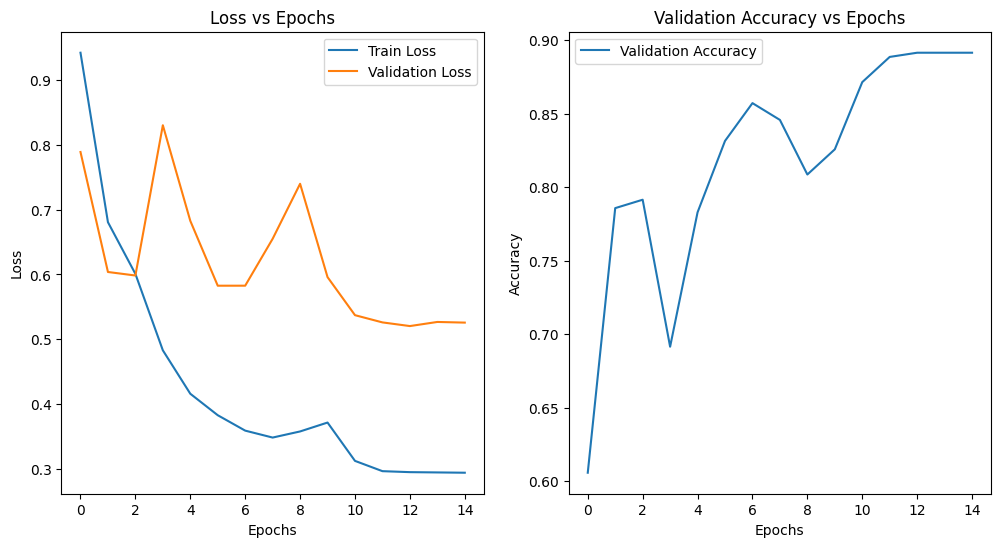

In [11]:
import matplotlib.pyplot as plt

# Training and validation loss curves
plt.figure(figsize=(12, 6))

# Plot for training loss and validation loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Validation Loss")
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Validation Accuracy curve
plt.subplot(1, 2, 2)
# Move the validation accuracy to CPU before plotting
val_acc_history_cpu = [acc.cpu().item() for acc in val_acc_history]  # Ensure this is on CPU
plt.plot(val_acc_history_cpu, label="Validation Accuracy")
plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Display the plot
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       127
           1       0.75      0.88      0.81       112
           2       0.86      0.75      0.80       112

    accuracy                           0.86       351
   macro avg       0.87      0.86      0.86       351
weighted avg       0.87      0.86      0.86       351



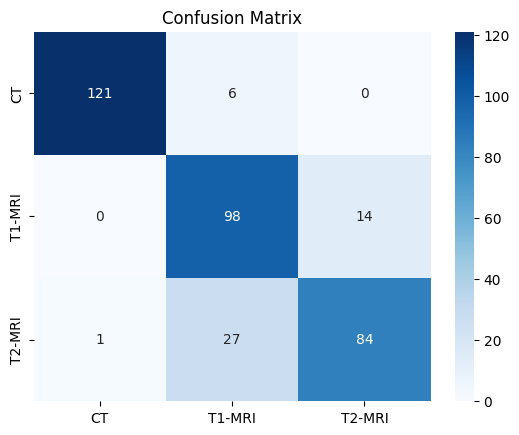

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import torch
import seaborn as sns

# Ensure device is defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Predict on test data
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Classification Report:")
print(classification_report(y_true, y_pred))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["CT", "T1-MRI", "T2-MRI"], yticklabels=["CT", "T1-MRI", "T2-MRI"])
plt.title("Confusion Matrix")
plt.show()


**MobileNetV3Large**

In [18]:
import timm
import torch.nn as nn
from torchvision import models
import torch.optim as optim
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.models import MobileNet_V3_Large_Weights
from torchvision.models import DenseNet121_Weights
# Define model selection with Dropout before final layer
def get_model(model_name):
    if model_name == "ConvNeXt-Tiny":
        model = timm.create_model("convnext_tiny.fb_in22k", pretrained=True)
        model.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(model.num_features * 7 * 7, 3)
        )
    elif model_name == "DenseNet-121":
        weights = DenseNet121_Weights.DEFAULT
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.classifier.in_features, 3)
        )
    elif model_name == "EfficientNet-V2-Small":
        model = timm.create_model("efficientnet_v2_s", pretrained=True)
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.classifier.in_features, 3)
        )
    elif model_name == "MobileNet-V3-Large":
        weights = MobileNet_V3_Large_Weights.DEFAULT 
        model = models.mobilenet_v3_large(weights=weights)
        model.classifier[3] = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.classifier[3].in_features, 3)
        )
    elif model_name == "ViT-Base/16":
        model = timm.create_model("vit_base_patch16_224", pretrained=True)
        model.head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.head.in_features, 3)
        )
    else:
        raise ValueError(f"Model {model_name} not recognized")
    return model

# Optimizer & Loss setup
def setup_optimizer(model):
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    return optimizer, criterion

# AMP scaler
scaler = torch.amp.GradScaler() if torch.cuda.is_available() else None

# Training & Evaluation
def train_and_evaluate(model, train_loader, val_loader, test_loader, optimizer, criterion, scheduler, epochs=12):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    best_model_wts = model.state_dict()
    best_acc = 0.0
    early_stopping_counter = 0
    train_loss_history = []
    val_loss_history = []
    val_acc_history = []
    train_acc_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        corrects = 0
        total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast(device_type='cuda') if torch.cuda.is_available() else torch.no_grad():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            if scaler:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
            total += labels.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_loss_history.append(epoch_train_loss)
        epoch_train_acc = corrects.double() / total
        train_acc_history.append(epoch_train_acc)

        # Validation phase
        model.eval()
        running_loss = 0.0
        corrects = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                corrects += torch.sum(preds == labels.data)
                total += labels.size(0)

        epoch_val_loss = running_loss / len(val_loader.dataset)
        val_loss_history.append(epoch_val_loss)
        epoch_val_acc = corrects.double() / total
        val_acc_history.append(epoch_val_acc)

        scheduler.step(epoch_val_acc)
        print(f"Current LR: {scheduler.optimizer.param_groups[0]['lr']:.6f}")

        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = model.state_dict()
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.4f} - Train Accuracy: {epoch_train_acc:.4f} - "
              f"Validation Loss: {epoch_val_loss:.4f} - Validation Accuracy: {epoch_val_acc:.4f}")

        if early_stopping_counter >= 3:
            print("Early stopping triggered.")
            break

    # Load best model
    model.load_state_dict(best_model_wts)
    torch.save(model.state_dict(), "best_model.pth")

    # Final test evaluation
    model.eval()
    corrects = 0
    total = 0
    running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
            total += labels.size(0)

    epoch_test_loss = running_loss / len(test_loader.dataset)
    epoch_test_acc = corrects.double() / total

    # ✅ Final Summary Output
    print("\n" + "="*40)
    print("✅ Final Results")
    print(f"Best Validation Accuracy: {best_acc:.4f}")
    print(f"Final Train Accuracy: {train_acc_history[-1]:.4f}")
    print(f"Final Validation Accuracy: {val_acc_history[-1]:.4f}")
    print(f"Test Loss: {epoch_test_loss:.4f}")
    print(f"Test Accuracy: {epoch_test_acc:.4f}")
    print("="*40)

    return model, train_loss_history, val_loss_history, val_acc_history, train_acc_history, epoch_test_acc

# Run training
model_name = "MobileNet-V3-Large"
model = get_model(model_name)
optimizer, criterion = setup_optimizer(model)
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model, train_loss_history, val_loss_history, val_acc_history, train_acc_history, test_acc = train_and_evaluate(
    model, train_loader, val_loader, test_loader, optimizer, criterion, scheduler, epochs=12)


Current LR: 0.000100
Epoch 1/12 - Train Loss: 0.8353 - Train Accuracy: 0.6503 - Validation Loss: 0.7343 - Validation Accuracy: 0.7200
Current LR: 0.000100
Epoch 2/12 - Train Loss: 0.5508 - Train Accuracy: 0.8549 - Validation Loss: 0.6552 - Validation Accuracy: 0.8057
Current LR: 0.000100
Epoch 3/12 - Train Loss: 0.4596 - Train Accuracy: 0.9186 - Validation Loss: 0.6233 - Validation Accuracy: 0.8086
Current LR: 0.000100
Epoch 4/12 - Train Loss: 0.4186 - Train Accuracy: 0.9369 - Validation Loss: 0.6348 - Validation Accuracy: 0.7943
Current LR: 0.000100
Epoch 5/12 - Train Loss: 0.3845 - Train Accuracy: 0.9657 - Validation Loss: 0.5942 - Validation Accuracy: 0.8286
Current LR: 0.000100
Epoch 6/12 - Train Loss: 0.3616 - Train Accuracy: 0.9792 - Validation Loss: 0.5712 - Validation Accuracy: 0.8429
Current LR: 0.000100
Epoch 7/12 - Train Loss: 0.3456 - Train Accuracy: 0.9878 - Validation Loss: 0.5013 - Validation Accuracy: 0.9029
Current LR: 0.000100
Epoch 8/12 - Train Loss: 0.3420 - Train A

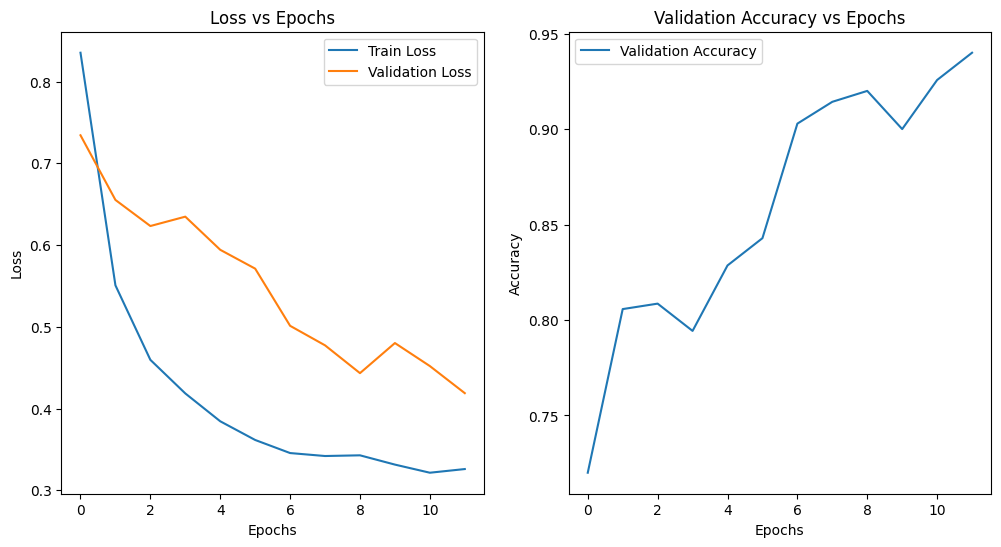

In [19]:
import matplotlib.pyplot as plt

# Training and validation loss curves
plt.figure(figsize=(12, 6))

# Plot for training loss and validation loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Validation Loss")
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Validation Accuracy curve
plt.subplot(1, 2, 2)
# Move the validation accuracy to CPU before plotting
val_acc_history_cpu = [acc.cpu().item() for acc in val_acc_history]  # Ensure this is on CPU
plt.plot(val_acc_history_cpu, label="Validation Accuracy")
plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Display the plot
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       107
           1       0.89      0.91      0.90       126
           2       0.91      0.90      0.90       118

    accuracy                           0.93       351
   macro avg       0.93      0.93      0.93       351
weighted avg       0.93      0.93      0.93       351



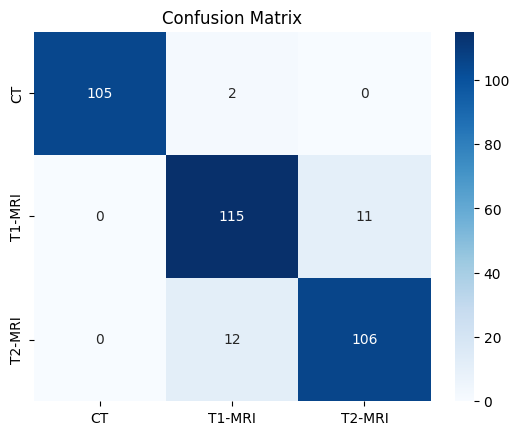

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import torch
import seaborn as sns

# Ensure device is defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Predict on test data
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Classification Report:")
print(classification_report(y_true, y_pred))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["CT", "T1-MRI", "T2-MRI"], yticklabels=["CT", "T1-MRI", "T2-MRI"])
plt.title("Confusion Matrix")
plt.show()


**DenseNet-121**

In [21]:
import timm
import torch.nn as nn
from torchvision import models
import torch.optim as optim
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.models import MobileNet_V3_Large_Weights
from torchvision.models import DenseNet121_Weights
# Define model selection with Dropout before final layer
def get_model(model_name):
    if model_name == "ConvNeXt-Tiny":
        model = timm.create_model("convnext_tiny.fb_in22k", pretrained=True)
        model.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(model.num_features * 7 * 7, 3)
        )
    elif model_name == "DenseNet-121":
        weights = DenseNet121_Weights.DEFAULT
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.classifier.in_features, 3)
        )
    elif model_name == "EfficientNet-V2-Small":
        model = timm.create_model("efficientnet_v2_s", pretrained=True)
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.classifier.in_features, 3)
        )
    elif model_name == "MobileNet-V3-Large":
        weights = MobileNet_V3_Large_Weights.DEFAULT 
        model = models.mobilenet_v3_large(weights=weights)
        model.classifier[3] = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.classifier[3].in_features, 3)
        )
    elif model_name == "ViT-Base/16":
        model = timm.create_model("vit_base_patch16_224", pretrained=True)
        model.head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.head.in_features, 3)
        )
    else:
        raise ValueError(f"Model {model_name} not recognized")
    return model

# Optimizer & Loss setup
def setup_optimizer(model):
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    return optimizer, criterion

# AMP scaler
scaler = torch.amp.GradScaler() if torch.cuda.is_available() else None

# Training & Evaluation
def train_and_evaluate(model, train_loader, val_loader, test_loader, optimizer, criterion, scheduler, epochs=12):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    best_model_wts = model.state_dict()
    best_acc = 0.0
    early_stopping_counter = 0
    train_loss_history = []
    val_loss_history = []
    val_acc_history = []
    train_acc_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        corrects = 0
        total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast(device_type='cuda') if torch.cuda.is_available() else torch.no_grad():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            if scaler:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
            total += labels.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_loss_history.append(epoch_train_loss)
        epoch_train_acc = corrects.double() / total
        train_acc_history.append(epoch_train_acc)

        # Validation phase
        model.eval()
        running_loss = 0.0
        corrects = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                corrects += torch.sum(preds == labels.data)
                total += labels.size(0)

        epoch_val_loss = running_loss / len(val_loader.dataset)
        val_loss_history.append(epoch_val_loss)
        epoch_val_acc = corrects.double() / total
        val_acc_history.append(epoch_val_acc)

        scheduler.step(epoch_val_acc)
        print(f"Current LR: {scheduler.optimizer.param_groups[0]['lr']:.6f}")

        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = model.state_dict()
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.4f} - Train Accuracy: {epoch_train_acc:.4f} - "
              f"Validation Loss: {epoch_val_loss:.4f} - Validation Accuracy: {epoch_val_acc:.4f}")

        if early_stopping_counter >= 5:
            print("Early stopping triggered.")
            break

    # Load best model
    model.load_state_dict(best_model_wts)
    torch.save(model.state_dict(), "best_model.pth")

    # Final test evaluation
    model.eval()
    corrects = 0
    total = 0
    running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
            total += labels.size(0)

    epoch_test_loss = running_loss / len(test_loader.dataset)
    epoch_test_acc = corrects.double() / total

    # ✅ Final Summary Output
    print("\n" + "="*40)
    print("✅ Final Results")
    print(f"Best Validation Accuracy: {best_acc:.4f}")
    print(f"Final Train Accuracy: {train_acc_history[-1]:.4f}")
    print(f"Final Validation Accuracy: {val_acc_history[-1]:.4f}")
    print(f"Test Loss: {epoch_test_loss:.4f}")
    print(f"Test Accuracy: {epoch_test_acc:.4f}")
    print("="*40)

    return model, train_loss_history, val_loss_history, val_acc_history, train_acc_history, epoch_test_acc

# Run training
model_name = "DenseNet-121"
model = get_model(model_name)
optimizer, criterion = setup_optimizer(model)
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model, train_loss_history, val_loss_history, val_acc_history, train_acc_history, test_acc = train_and_evaluate(
    model, train_loader, val_loader, test_loader, optimizer, criterion, scheduler, epochs=12)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 139MB/s] 


Current LR: 0.000100
Epoch 1/12 - Train Loss: 0.7954 - Train Accuracy: 0.6742 - Validation Loss: 0.5481 - Validation Accuracy: 0.8486
Current LR: 0.000100
Epoch 2/12 - Train Loss: 0.5058 - Train Accuracy: 0.8867 - Validation Loss: 0.5768 - Validation Accuracy: 0.8343
Current LR: 0.000100
Epoch 3/12 - Train Loss: 0.4410 - Train Accuracy: 0.9296 - Validation Loss: 0.4312 - Validation Accuracy: 0.9257
Current LR: 0.000100
Epoch 4/12 - Train Loss: 0.3819 - Train Accuracy: 0.9712 - Validation Loss: 0.4051 - Validation Accuracy: 0.9400
Current LR: 0.000100
Epoch 5/12 - Train Loss: 0.3650 - Train Accuracy: 0.9816 - Validation Loss: 0.4467 - Validation Accuracy: 0.9171
Current LR: 0.000100
Epoch 6/12 - Train Loss: 0.3676 - Train Accuracy: 0.9810 - Validation Loss: 0.4464 - Validation Accuracy: 0.9229
Current LR: 0.000050
Epoch 7/12 - Train Loss: 0.3581 - Train Accuracy: 0.9859 - Validation Loss: 0.4579 - Validation Accuracy: 0.9086
Current LR: 0.000050
Epoch 8/12 - Train Loss: 0.3475 - Train A

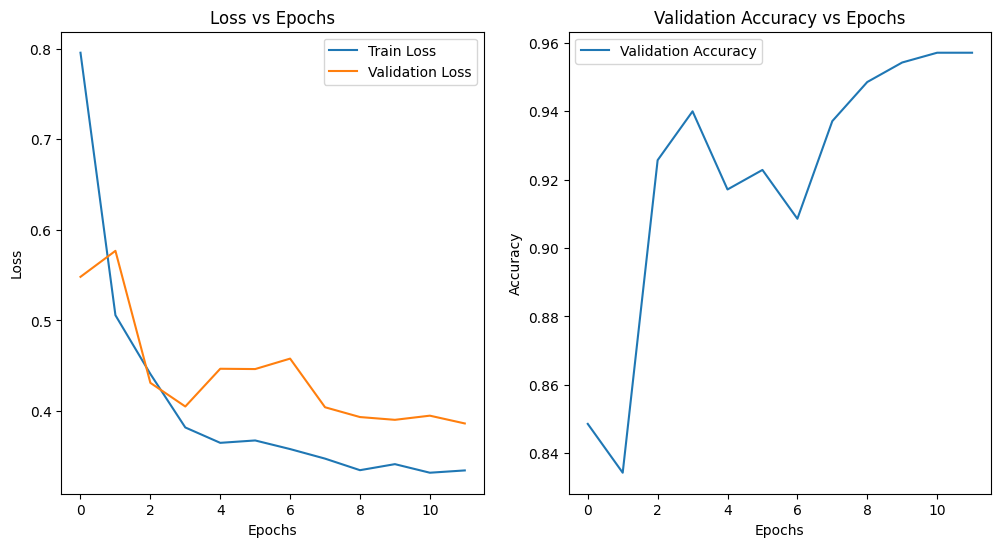

In [22]:
import matplotlib.pyplot as plt

# Training and validation loss curves
plt.figure(figsize=(12, 6))

# Plot for training loss and validation loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Validation Loss")
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Validation Accuracy curve
plt.subplot(1, 2, 2)
# Move the validation accuracy to CPU before plotting
val_acc_history_cpu = [acc.cpu().item() for acc in val_acc_history]  # Ensure this is on CPU
plt.plot(val_acc_history_cpu, label="Validation Accuracy")
plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Display the plot
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       107
           1       0.93      0.90      0.91       126
           2       0.89      0.93      0.91       118

    accuracy                           0.94       351
   macro avg       0.94      0.94      0.94       351
weighted avg       0.94      0.94      0.94       351



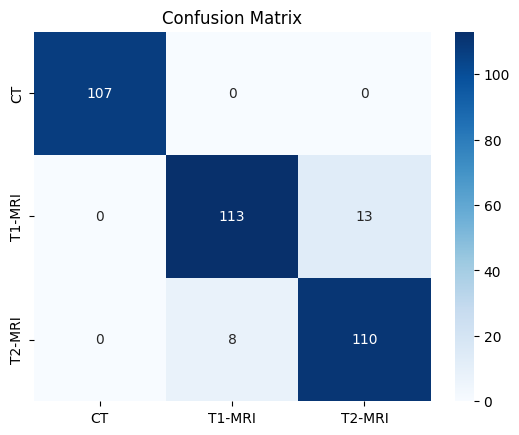

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import torch
import seaborn as sns

# Ensure device is defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Predict on test data
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Classification Report:")
print(classification_report(y_true, y_pred))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["CT", "T1-MRI", "T2-MRI"], yticklabels=["CT", "T1-MRI", "T2-MRI"])
plt.title("Confusion Matrix")
plt.show()


**ConvoNet-Tiny**

In [24]:
import timm
import torch.nn as nn
from torchvision import models
import torch.optim as optim
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.models import MobileNet_V3_Large_Weights, DenseNet121_Weights

# Define model selection with Dropout before final layer
def get_model(model_name):
    if model_name == "ConvNeXt-Tiny":
        model = timm.create_model("convnext_tiny.fb_in22k", pretrained=True)
        # Freeze all layers
        for param in model.parameters():
            param.requires_grad = False
        # Unfreeze last stage only
        for param in model.stages[-1].parameters():
            param.requires_grad = True
        model.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(model.num_features * 7 * 7, 3)
        )
    elif model_name == "DenseNet-121":
        weights = DenseNet121_Weights.DEFAULT
        model = models.densenet121(weights=weights)
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.classifier.in_features, 3)
        )
    elif model_name == "EfficientNet-V2-Small":
        model = timm.create_model("efficientnet_v2_s", pretrained=True)
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.classifier.in_features, 3)
        )
    elif model_name == "MobileNet-V3-Large":
        weights = MobileNet_V3_Large_Weights.DEFAULT
        model = models.mobilenet_v3_large(weights=weights)
        model.classifier[3] = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.classifier[3].in_features, 3)
        )
    elif model_name == "ViT-Base/16":
        model = timm.create_model("vit_base_patch16_224", pretrained=True)
        model.head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.head.in_features, 3)
        )
    else:
        raise ValueError(f"Model {model_name} not recognized")
    return model

# Optimizer & Loss setup
def setup_optimizer(model):
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    return optimizer, criterion

# AMP scaler
scaler = torch.amp.GradScaler() if torch.cuda.is_available() else None

# Training & Evaluation
def train_and_evaluate(model, train_loader, val_loader, test_loader, optimizer, criterion, scheduler, model_name, epochs=15):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    best_model_wts = model.state_dict()
    best_acc = 0.0
    early_stopping_counter = 0
    train_loss_history = []
    val_loss_history = []
    val_acc_history = []
    train_acc_history = []

    for epoch in range(epochs):
        # Unfreeze all layers after 5 epochs for ConvNeXt-Tiny
        if model_name == "ConvNeXt-Tiny" and epoch == 5:
            for param in model.parameters():
                param.requires_grad = True
            optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

        model.train()
        running_loss = 0.0
        corrects = 0
        total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast(device_type='cuda') if torch.cuda.is_available() else torch.no_grad():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            if scaler:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
            total += labels.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_loss_history.append(epoch_train_loss)
        epoch_train_acc = corrects.double() / total
        train_acc_history.append(epoch_train_acc)

        # Validation phase
        model.eval()
        running_loss = 0.0
        corrects = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                corrects += torch.sum(preds == labels.data)
                total += labels.size(0)

        epoch_val_loss = running_loss / len(val_loader.dataset)
        val_loss_history.append(epoch_val_loss)
        epoch_val_acc = corrects.double() / total
        val_acc_history.append(epoch_val_acc)

        scheduler.step(epoch_val_acc)
        print(f"Current LR: {scheduler.optimizer.param_groups[0]['lr']:.6f}")

        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = model.state_dict()
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.4f} - Train Accuracy: {epoch_train_acc:.4f} - "
              f"Validation Loss: {epoch_val_loss:.4f} - Validation Accuracy: {epoch_val_acc:.4f}")

        if early_stopping_counter >= 5:
            print("Early stopping triggered.")
            break

    # Load best model
    model.load_state_dict(best_model_wts)
    torch.save(model.state_dict(), "best_model.pth")

    # Final test evaluation
    model.eval()
    corrects = 0
    total = 0
    running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
            total += labels.size(0)

    epoch_test_loss = running_loss / len(test_loader.dataset)
    epoch_test_acc = corrects.double() / total

    # ✅ Final Summary Output
    print("\n" + "="*40)
    print("✅ Final Results")
    print(f"Best Validation Accuracy: {best_acc:.4f}")
    print(f"Final Train Accuracy: {train_acc_history[-1]:.4f}")
    print(f"Final Validation Accuracy: {val_acc_history[-1]:.4f}")
    print(f"Test Loss: {epoch_test_loss:.4f}")
    print(f"Test Accuracy: {epoch_test_acc:.4f}")
    print("="*40)

    return model, train_loss_history, val_loss_history, val_acc_history, train_acc_history, epoch_test_acc

# Run training
model_name = "ConvNeXt-Tiny"  # Change this to desired model
model = get_model(model_name)
optimizer, criterion = setup_optimizer(model)
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model, train_loss_history, val_loss_history, val_acc_history, train_acc_history, test_acc = train_and_evaluate(
    model, train_loader, val_loader, test_loader, optimizer, criterion, scheduler, model_name, epochs=15)


model.safetensors:   0%|          | 0.00/178M [00:00<?, ?B/s]

Current LR: 0.000100
Epoch 1/15 - Train Loss: 1.1408 - Train Accuracy: 0.6620 - Validation Loss: 0.6060 - Validation Accuracy: 0.8686
Current LR: 0.000100
Epoch 2/15 - Train Loss: 0.5457 - Train Accuracy: 0.8990 - Validation Loss: 0.5187 - Validation Accuracy: 0.8857
Current LR: 0.000100
Epoch 3/15 - Train Loss: 0.4671 - Train Accuracy: 0.9290 - Validation Loss: 0.4895 - Validation Accuracy: 0.9057
Current LR: 0.000100
Epoch 4/15 - Train Loss: 0.4094 - Train Accuracy: 0.9602 - Validation Loss: 0.4725 - Validation Accuracy: 0.9257
Current LR: 0.000100
Epoch 5/15 - Train Loss: 0.3860 - Train Accuracy: 0.9786 - Validation Loss: 0.4431 - Validation Accuracy: 0.9314
Current LR: 0.000100
Epoch 6/15 - Train Loss: 0.5566 - Train Accuracy: 0.8781 - Validation Loss: 0.4910 - Validation Accuracy: 0.8714
Current LR: 0.000100
Epoch 7/15 - Train Loss: 0.3788 - Train Accuracy: 0.9755 - Validation Loss: 0.4120 - Validation Accuracy: 0.9514
Current LR: 0.000100
Epoch 8/15 - Train Loss: 0.3561 - Train A

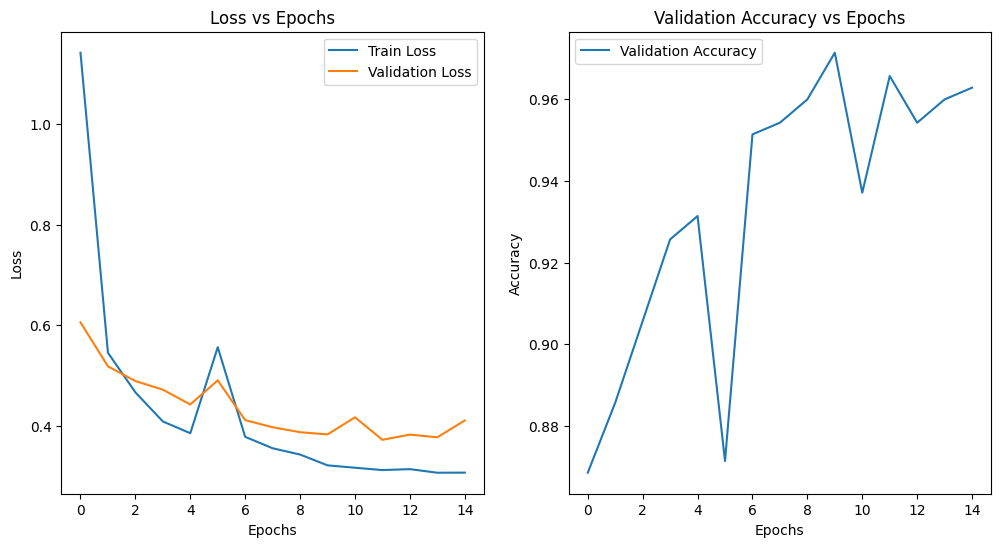

In [25]:
import matplotlib.pyplot as plt

# Training and validation loss curves
plt.figure(figsize=(12, 6))

# Plot for training loss and validation loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Validation Loss")
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Validation Accuracy curve
plt.subplot(1, 2, 2)
# Move the validation accuracy to CPU before plotting
val_acc_history_cpu = [acc.cpu().item() for acc in val_acc_history]  # Ensure this is on CPU
plt.plot(val_acc_history_cpu, label="Validation Accuracy")
plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Display the plot
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       107
           1       0.96      0.94      0.95       126
           2       0.98      0.94      0.96       118

    accuracy                           0.96       351
   macro avg       0.96      0.96      0.96       351
weighted avg       0.96      0.96      0.96       351



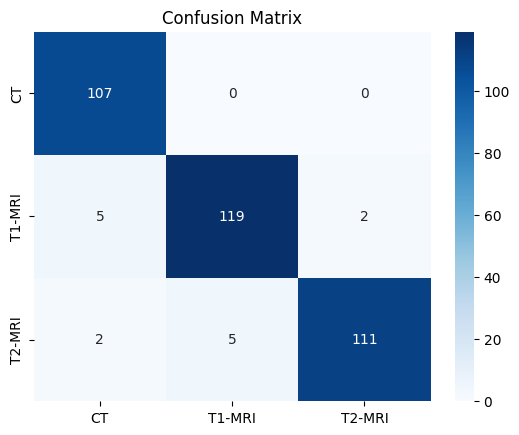

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import torch
import seaborn as sns

# Ensure device is defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Predict on test data
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Classification Report:")
print(classification_report(y_true, y_pred))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["CT", "T1-MRI", "T2-MRI"], yticklabels=["CT", "T1-MRI", "T2-MRI"])
plt.title("Confusion Matrix")
plt.show()
